<a href="https://colab.research.google.com/github/gabrielebirri/CLAMA_Project/blob/main/DTL_Melanoma_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Melanoma identification through deep transfer learning**  

Author: Gabriele Birri  
Date: March 2026


## Introduction  
### Abstract
The objective of this experimental research is to conduct a comparative analysis of diverse Convolutional Neural Network (CNN) architectures to assess their performance in the automated classification of cutaneous lesions as benign or malignant (melanoma). Given the inherent constraints of medical imaging datasets, a transfer learning methodology is adopted. Specifically, three prominent architectures, pre-trained on the ImageNet database, are employed as feature extractors to evaluate their diagnostic efficacy. To ensure experimental integrity and mitigate methodological biases, a standardized training and evaluation pipeline is maintained across all models.

The architectures are adapted for binary classification by substituting the original global classifier or fully connected layer with a task-specific head. The optimization follows a two-phase fine-tuning strategy: an initial stage where the convolutional backbone remains frozen to stabilize the new classifier's weights, followed by a selective unfreezing of deeper layers to facilitate domain-specific feature adaptation. This dual-stage approach is designed to enhance task specialization while preserving the generalization capabilities of the pre-trained weights. Furthermore, a grad-CAM technique is implemented to gain a sensible evidence of the spatial attention of the model.

The study utilizes a dataset of approximately 10,000 dermoscopic images, sourced from a publicly available repository and balanced between benign and malignant classes. The performance of the respective architectures is rigorously quantified using standard clinical evaluation metrics, providing a comprehensive perspective on the suitability of different CNN backbones for computer-aided diagnosis in dermatology.  

**Dataset used:** https://www.kaggle.com/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images

### The Significance of early Melanoma Detection
Melanoma is a malignant neoplasm arising from the oncogenic transformation of melanocytes, the pigment-producing cells located in the basal layer of the epidermis. While it accounts for a minority of skin cancer cases, it is responsible for the vast majority of skin cancer-related fatalities due to its aggressive nature and high metastatic potential. Precision and speed in diagnosis are paramount; according to the American Cancer Society (2025), the 5-year survival rate exceeds 99% when detected at a localized stage, but plummets to approximately 35% once distant metastasis occurs. Consequently, developing automated, highly accurate diagnostic tools is a critical priority in reducing clinical variability and improving patient outcomes through early intervention.

**Key References**
* American Cancer Society. (2025). Cancer Facts & Figures 2025. Atlanta: American Cancer Society.  

* Haenssle, M. A., et al. (2018). Man against machine: diagnostic performance of a deep learning convolutional neural network for dermoscopic melanoma recognition in comparison to 58 dermatologists. Annals of Oncology, 29(8), 1836-1842.  

* World Health Organization. (2024). Global Cancer Statistics: Skin Melanoma.


# Setup

In [2]:
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Detected environment: Colab")
    print("Proceeding to download grad-cam library")
    !pip install grad-cam

else:
    print("Detected environment: Local")

Detected environment: Colab
Proceeding to download grad-cam library
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 84.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=463e008a80bb7a770febcbd1693067a2894bc252c6c9a78aacb5ce601fd9da2b
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [3]:
## IMPORT PACKAGES ##

# Utility
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
from tqdm import tqdm
import os
from pathlib import Path
from sklearn.model_selection import train_test_split
import copy
import sys

# PyTorch
import torch
from torch import nn
import torch.optim as optim
import torchvision
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

# Grad-CAM
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image


print("all clear")

all clear


## Hardware acceleration  

The versatility of the PyTorch framework allows for efficient interfacing with cutting-edge hardware acceleration techniques. To ensure portability and performance, the following code establishes a device-agnostic environment, enabling the automated selection of the most performant available backend (CUDA or MPS).

In [4]:
# Setting up the agnostic device code
if torch.backends.mps.is_available():
    device = "mps"  # For MPS acceleration
elif torch.cuda.is_available():
    device = "cuda" # For CUDA acceleration
else:
    device = "cpu"

print(f"Device: {device}")

Device: cuda


# Pre-processing of the image data

**Data augmentation**  

To improve the generalization capability of the model and mitigate overfitting, a data augmentation strategy is applied to the training dataset. The selected transformations are carefully chosen to preserve the clinically relevant diagnostic features of melanoma while introducing controlled variability in the input images.  

The transformations employed include resizing, horizontal flipping, vertical flipping and rotation. Image resizing standardizes the input dimensions to match the architectural requirements of the neural network, ensuring consistent tensor shapes across the dataset. Horizontal and vertical flips are applied to simulate variations in lesion orientation. Since melanoma diagnosis is independent of the spatial orientation of the lesion, these transformations do not alter essential diagnostic criteria such as asymmetry, border irregularity, color heterogeneity, or structural patterns. Similarly, controlled rotations are introduced to further increase rotational invariance, reflecting the fact that skin lesions may be photographed from different angles without affecting their pathological characteristics.  

It's important to note that no transformations that could distort morphological or chromatic properties are applied. The selected augmentations preserve the intrinsic geometrical and textural features that are critical for melanoma identification, thereby maintaining clinical validity while enhancing model robustness.  

**Image normalization**  

To minimize the objective function more efficiently and maintain architectural consistency with the pre-trained EfficientNetV2-S backbone, a Z-score normalization was applied. This transformation centers the pixel intensity distribution around zero and scales it to unit variance, preventing gradient instability and ensuring that the visual features extracted are robust to varying lighting conditions of the source mobile devices.

**Dataset splitting**  

The dataset is splitted into three subsets (of approximately the sizes indicated):
* Training (80%)
* Validation (10%)
* Test (10%)

The training set is used to optimize the model parameters through backpropagation. The validation set is employed during development to tune hyperparameters, monitor generalization performance, and implement strategies such as early stopping. The test set, which remains completely unseen during training and validation, is used exclusively for the final performance evaluation to provide an unbiased estimate of the model’s predictive capability on new data.  
This structured splitting ensures methodological rigor and prevents information leakage, thereby supporting reliable assessment of the model’s real-world applicability.

In [7]:
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Detected environment: Colab")
    # Downloading the dataset from Kaggle
    root = kagglehub.dataset_download("hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images")
    train_path = '/kaggle/input/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/train'
    test_path = '/kaggle/input/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/test'

else:
    print("Detected environment: Local")
    root = './melanoma_cancer_dataset'
    train_path = os.path.join(root, "train")
    test_path = os.path.join(root, "test")

Detected environment: Colab
Using Colab cache for faster access to the 'melanoma-skin-cancer-dataset-of-10000-images' dataset.


In [8]:
# Let's define some useful transformations for data augmentation
# NOTE: the choosen transformations preserve the diagnostic features of the melanoma
torch.manual_seed(42)
imagenet_mean = [0.485, 0.456, 0.406]   # mean used in model training
imagenet_std = [0.229, 0.224, 0.225]    # standard deviation used in model training

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )

])

# Building the train dataset using ImageFolder
train_dataset = datasets.ImageFolder(
    root=train_path,
    transform=train_transform
)

# Building validation and test datasets using ImageFolder
test_validation_dataset = datasets.ImageFolder(
    root=test_path,
    transform=test_transform
)

targets = test_validation_dataset.targets

val_indices, test_indices = train_test_split(
    range(len(test_validation_dataset)),
    test_size=0.5,
    stratify=targets,
    random_state=42
)

validation_dataset = torch.utils.data.Subset(test_validation_dataset, val_indices)
test_dataset = torch.utils.data.Subset(test_validation_dataset, test_indices)

print(train_dataset.class_to_idx)
print(len(train_dataset))
print(len(validation_dataset))
print(len(test_dataset))

{'benign': 0, 'malignant': 1}
9605
500
500


Benign


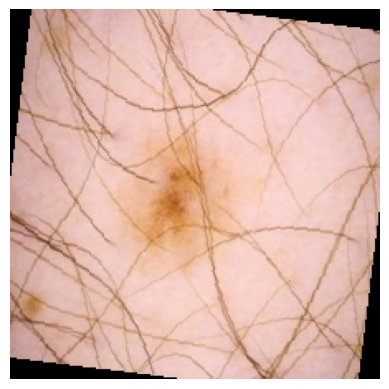

In [9]:
# Let's visualize a sample of our train dataset
# Each image comes in a [3,224,224] shape, or the standard [C,H,W]

# Defining a function to better visualize the image (without false colours)
def im_show(tensor):
    img = tensor.squeeze(0).cpu().detach().numpy().transpose((1, 2, 0))
    img = np.clip(img * imagenet_std + imagenet_mean, 0, 1)
    plt.imshow(img)
    plt.axis('off')

img, label = train_dataset[1508]    # Visualized tensor
im_show(img)

if label == 0:
  print("Benign")
else:
  print("Malignant")

In [10]:
# DATA LOADERS
batch_size = 32

# This will allow to load the dataset in batches

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# For the validation and test datasets, shuffling is not needed
val_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Model choice and methods
**Choice of the model**  
In this notebook we are going to compare different models in order to assess differences in performance between them and optimize the choice for the best models. We are going to evaluate:  

* DenseNet121: widely adopted in the medical imaging literature for melanoma classification due to its strong capability to capture fine-grained visual patterns and subtle chromatic variations, which are critical diagnostic features in this task.  

* ResNet50  

* EfficientNet  

**Training phase**

We are going to divide the training phase in two subfases:  

*   Training of the classifier (3-7 epochs)  

*   Fine tuning of the backbone (10-15 epochs)  

The reason for this particular choice lays in the pre-training of our chosen model: if we update all the parameters already in the first epochs we may run into the destruction of the basic feature recognition learned through pre-training using ImageNet (a much larger dataset than the one we used); this phenomenon is called catastrophic forgetting.    
The optimal fine tuning of the model will thus consist first in the training of the classifier, and then in the fine tuning of the actual backbone of the CNN model.

**Optimizer:**
The choice of ADAM as optimizer is driven by the necessity of the detection of fairy small features. In this task Adam thrives the most because of its stunning gradient adaptation. In the second phase of the training ADAM will be replaced by SGD in order to limit oscillations and achieving a better convergence.


In [11]:
from torchvision import models

# Defining functions to build each model
def build_densenet():
    model = models.densenet121(weights="IMAGENET1K_V1")
    model.classifier = nn.Linear(model.classifier.in_features, 1)   # Initializing the classifier to be binary
    return model

def build_resnet():
    model = models.resnet50(weights="IMAGENET1K_V1")
    model.fc = nn.Linear(model.fc.in_features, 1)   # Initializing the fc layer to be binary
    return model

def build_efficientnet():
    model = models.efficientnet_v2_s(weights="IMAGENET1K_V1")
    in_features = model.classifier[1].in_features
    # Initializing the classifier to be binary
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.2, inplace=True),
        nn.Linear(in_features, 1),
    )
    return model

In [12]:
# Choosing the model to evaluate
model_name = "EfficientNet" # Namecode for the device

# Downloading and preparing the model
if model_name == "DenseNet121":
    model = build_densenet()
    print(f"Model: {model_name} \nStatus: Loaded correctly")

elif model_name == "ResNet50":
    model = build_resnet()
    print(f"Model: {model_name} \nStatus: Loaded correctly")

elif model_name == "EfficientNet":
    model = build_efficientnet()
    print(f"Model: {model_name}_v2_s \nStatus: Loaded correctly")

model = model.to(device) # Moving the model to selected device


Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 208MB/s]


Model: EfficientNet_v2_s 
Status: Loaded correctly


# Training pipeline

Despite the choice of the model, the training and testing pipelines will follow the same procedures, in order to not create experimental biases and to better confront models and their performances.

In [13]:
# CRITERION
# The loss function is set up to have an higher penalization on malignant
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([1.2]).to(device))

# Learning rate
learning_rate = 0.001

# OPTIMIZER
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

### First training phase

In [ ]:
def freeze_backbone(model):
    # First all the parameters of the model are being freezed
    for param in model.parameters():
        param.requires_grad = False

    # Only the last layer is unfreezed (classifier or fc)
    # The pipeline is studied to be compatible with the most known models for medical imaging
    # NOTE: if the model is not supported you need to freeze and unfreeze the layers manually
    # This operation depends on the architecture of the model

    if hasattr(model, 'fc'):
        # Case: ResNet, Inception
        for param in model.fc.parameters():
            param.requires_grad = True
        print("Backbone freezed. Layer 'fc' active.")

    elif hasattr(model, 'classifier'):
        # Case: VGG, DenseNet, EfficientNet
        for param in model.classifier.parameters():
            param.requires_grad = True
        print("Backbone freezed. Layer 'classifier' active.")

    else:
        print("Unable to automatically recognize model layers")

def unfreeze_backbone(model):
    # All the parameters are unfreezed
    for param in model.parameters():
        param.requires_grad = True
    print("Backbone unfreezed")


In [ ]:
from sklearn.metrics import precision_score, recall_score

# TRAINING LOOP
def training_loop(epochs, threshold):
    # TRAINING BENCHMARKS
    train_loss = []
    train_acc = []
    train_precision = []
    train_recall = []

    # VALIDATION BENCHMARKS
    val_loss = []
    val_acc = []
    val_precision = []
    val_recall = []


    for epoch in range(epochs):
        model.train()

        correct, total = 0, 0       # Track correct predictions and total samples
        running_loss = 0.0          # Track the running loss for the training step
        all_train_preds = []        # List to store all predictions for precision and recall during training
        all_train_labels = []       # List to store all true labels for precision and recall during training

        # Progress bar using tqdm
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)

            labels = labels.float().unsqueeze(1)

            outputs = model(images) # Gets model predictions

            loss = criterion(outputs, labels)
            optimizer.zero_grad()   # Reset gradients from the previous step
            loss.backward()         # Compute gradients
            optimizer.step()        # Update model parameters

            # Applying sigmoid to outputs and setting threshold as indicated
            preds = (torch.sigmoid(outputs) > threshold).int().squeeze(1)

            # Update the total number of samples and the number of correct predictions
            total += labels.size(0)
            correct += (preds == labels.squeeze(1).int()).sum().item()

            # Add the loss for this batch to the running loss
            running_loss += loss.item()

            # Store predictions and true labels for precision and recall calculation
            all_train_preds.extend(preds.cpu().numpy())  # Move predictions to CPU for metrics calculation
            all_train_labels.extend(labels.squeeze(1).int().cpu().numpy())  # Move true labels to CPU for metrics calculation


        # Calculate training loss, accuracy, precision, and recall for this epoch
        avg_train_loss = running_loss / len(train_loader)
        train_acc.append(correct / total)
        train_loss.append(avg_train_loss)

        train_precision = precision_score(all_train_labels, all_train_preds, average='weighted', zero_division=1)
        train_recall = recall_score(all_train_labels, all_train_preds, average='weighted', zero_division=1)

        # Validation step
        model.eval()  # Set the model to evaluation mode (no gradient calculation)

        correct, total = 0, 0  # Reset correct and total for validation
        running_val_loss = 0.0  # Track the validation loss
        all_val_preds = []  # List to store all predictions for precision and recall during validation
        all_val_labels = []  # List to store all true labels for precision and recall during validation

        # VALIDATION

        # No gradient calculation during validation
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                # Reshape labels to match model output and cast to float
                labels = labels.float().unsqueeze(1)

                outputs = model(images)

                # Calculate the loss for validation
                loss = criterion(outputs, labels)
                running_val_loss += loss.item()

                # For accuracy, precision, recall, we need to convert logits to binary predictions
                # Apply sigmoid to outputs and then threshold at 0.5
                preds = (torch.sigmoid(outputs) > threshold).int().squeeze(1)

                total += labels.size(0)
                correct += (preds == labels.squeeze(1).int()).sum().item()

                # Store predictions and true labels for precision and recall calculation
                all_val_preds.extend(preds.cpu().numpy())
                all_val_labels.extend(labels.squeeze(1).int().cpu().numpy())

        # Calculate validation loss, accuracy, precision, and recall
        avg_val_loss = running_val_loss / len(val_loader)
        val_acc.append(correct / total)
        val_loss.append(avg_val_loss)

        val_precision = precision_score(all_val_labels, all_val_preds, average='weighted', zero_division=1)
        val_recall = recall_score(all_val_labels, all_val_preds, average='weighted', zero_division=1)

        # Print the results for this epoch
        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc[-1]:.2f}, Train Precision: {train_precision:.2f}, Train Recall: {train_recall:.2f}")
        print(f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc[-1]:.2f}, Val Precision: {val_precision:.2f}, Val Recall: {val_recall:.2f}")
        print(f"\n")


In [ ]:
## Training phase ##

freeze_backbone(model)

epochs = 5
threshold = 0.4

training_loop(epochs=epochs, threshold=threshold)

Backbone freezed. Layer 'classifier' active.


Epoch 1/3: 100%|██████████| 301/301 [01:17<00:00,  3.90it/s]



Epoch 1/3
Train Loss: 0.4535, Train Acc: 0.80, Train Precision: 0.82, Train Recall: 0.80
Val Loss: 0.3780, Val Acc: 0.82, Val Precision: 0.85, Val Recall: 0.82




Epoch 2/3: 100%|██████████| 301/301 [01:16<00:00,  3.94it/s]



Epoch 2/3
Train Loss: 0.3634, Train Acc: 0.85, Train Precision: 0.86, Train Recall: 0.85
Val Loss: 0.3339, Val Acc: 0.86, Val Precision: 0.87, Val Recall: 0.86




Epoch 3/3: 100%|██████████| 301/301 [01:16<00:00,  3.91it/s]



Epoch 3/3
Train Loss: 0.3565, Train Acc: 0.86, Train Precision: 0.86, Train Recall: 0.86
Val Loss: 0.3262, Val Acc: 0.85, Val Precision: 0.87, Val Recall: 0.85




### Second training phase

In this phase we are going to unfreeze the backbone in order to perform backpropagation through the whole model weights. It is important to limit the size of this phase in order to avoid destroying basic feature recognition as explained before. In this phase we are going to use the stochastic gradient descent (SGD) to enhance robustness on solution convergence and avoiding oscillations. We are going to implement the SDG with a momentum and a weight decay for better performances

In [ ]:
# Choosing SGD as optimizer for robustness
# Learning rate
learning_rate = 1e-4
momentum = 0.9
weight_decay = 1e-4

# OPTIMIZER
optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum, weight_decay=weight_decay)

In [ ]:
# Training phase 2

# NOW THE BACKBONE IS UNFREEZED
unfreeze_backbone(model)

epochs = 15
threshold = 0.4

training_loop(epochs=epochs, threshold=threshold)

Backbone unfreezed


Epoch 1/8: 100%|██████████| 301/301 [04:31<00:00,  1.11it/s]



Epoch 1/8
Train Loss: 0.3298, Train Acc: 0.87, Train Precision: 0.87, Train Recall: 0.87
Val Loss: 0.2867, Val Acc: 0.88, Val Precision: 0.89, Val Recall: 0.88




Epoch 2/8: 100%|██████████| 301/301 [04:37<00:00,  1.09it/s]



Epoch 2/8
Train Loss: 0.2885, Train Acc: 0.89, Train Precision: 0.89, Train Recall: 0.89
Val Loss: 0.2513, Val Acc: 0.90, Val Precision: 0.90, Val Recall: 0.90




...


Epoch 6/8
Train Loss: 0.2465, Train Acc: 0.91, Train Precision: 0.91, Train Recall: 0.91
Val Loss: 0.2112, Val Acc: 0.90, Val Precision: 0.90, Val Recall: 0.90




Epoch 7/8: 100%|██████████| 301/301 [05:08<00:00,  1.02s/it]



Epoch 7/8
Train Loss: 0.2384, Train Acc: 0.91, Train Precision: 0.91, Train Recall: 0.91
Val Loss: 0.2096, Val Acc: 0.91, Val Precision: 0.91, Val Recall: 0.91




Epoch 8/8: 100%|██████████| 301/301 [05:22<00:00,  1.07s/it]



Epoch 8/8
Train Loss: 0.2356, Train Acc: 0.91, Train Precision: 0.91, Train Recall: 0.91
Val Loss: 0.2237, Val Acc: 0.91, Val Precision: 0.91, Val Recall: 0.91




In [ ]:
# Defining paths
models_path = Path('./models')
models_path.mkdir(parents=True, exist_ok=True)
save_path = models_path / "Clama_v0.pth"
load_path = models_path / "Clama_v0.pth"

In [ ]:
# Saving state dict of the model
torch.save(model.state_dict(), save_path)
print(f"Model saved in: {save_path}")

Model saved in: models/Clama_v0.pth


# Testing pipeline

This section provides an evaluation of the model's generalisation capabilities. Performance metrics are assessed using a previously held-out test set, derived from the same distribution as the original dataset but consisting of unseen instances.

In [ ]:
# Choosing the model to test

if model_name == "DenseNet121":
    test_model = build_densenet()
    print(f"Model: {model_name} \nStatus: Loaded correctly")

elif model_name == "ResNet50":
    test_model = build_resnet()
    print(f"Model: {model_name} \nStatus: Loaded correctly")

elif model_name == "EfficientNet":
    test_model = build_efficientnet()
    print(f"Model: {model_name} \nStatus: Loaded correctly")

test_model.load_state_dict(torch.load(load_path))
test_model.to(device)
print(f"current test model: {load_path}")


Model: EfficientNet 
Status: Loaded correctly


/var/folders/dl/z510w3h552q7026crwy17wyh0000gn/T/ipykernel_37942/120829505.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  test_model.load_state_dict(torch.load(load_pa

current test model: models/Clama_v0.pth


In [ ]:
test_model.eval()
threshold = 0.25

test_loss = 0
correct = 0
total = 0

true_positives = 0
true_negatives = 0
false_positives = 0
false_negatives = 0

all_preds = []
all_labels = []

with torch.inference_mode():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device).float().unsqueeze(1)

        outputs = test_model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()

        probs = torch.sigmoid(outputs)
        preds = (probs > threshold).float()

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        true_positives += ((preds == 1) & (labels == 1)).sum().item()
        true_negatives += ((preds == 0) & (labels == 0)).sum().item()
        false_positives += ((preds == 1) & (labels == 0)).sum().item()
        false_negatives += ((preds == 0) & (labels == 1)).sum().item()

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Model tested")


Model tested


## Evaluation metrics  
To rigorously evaluate the model's diagnostic performance, we employ a suite of metrics derived from the Confusion Matrix. In the context of skin lesion classification, we define:  

* True Positive (TP): Melanomas correctly identified.  
* True Negative (TN): Benign lesions correctly identified.  
* False Positive (FP): Benign lesions misclassified as melanomas (leading to unnecessary biopsies).  
* False Negative (FN): Melanomas missed by the model (the most critical clinical error).  

**Accuracy**  
Accuracy represents the proportion of total correct predictions (both malignant and benign) over the entire dataset.

$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$  

Note: While intuitive, accuracy can be misleading if the dataset is imbalanced (e.g., significantly more benign samples than melanomas).  

**Precision (Positive Predictive Value)**  
Precision quantifies the reliability of a "malignant" prediction. It answers: Of all lesions flagged as melanoma, how many were actually cancerous?  

$\text{Precision} = \frac{TP}{TP + FP}$  

In a clinical setting, high precision reduces the rate of unnecessary and invasive follow-up procedures.  

**Recall (Sensitivity)**  
Recall, or Sensitivity, is the most critical metric in medical screening. It measures the model's ability to detect all actual cases of melanoma.  

$\text{Recall} = \frac{TP}{TP + FN}$  

Clinical Significance: A high Recall is paramount in dermatology to ensure that no malignant lesions remain untreated. A "False Negative" in this domain represents a missed diagnosis with potentially life-threatening consequences.  

**F1-Score**  
Provides the harmonic mean of Precision and Recall, offering a single balanced metric that accounts for both false positives and false negatives.  

$F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$  

**ROC and AUC**  
SEZIONE DA DEFINIRE

In [ ]:
# Metrics
test_loss /= len(test_loader)
accuracy = correct / total
precision = true_positives / (true_positives + false_positives + 1e-8)
recall = true_positives / (true_positives + false_negatives + 1e-8)

print("\nTEST RESULTS")
print(f"Loss: {test_loss:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")


TEST RESULTS
Loss: 0.2555
Accuracy: 0.8680
Precision: 0.8217
Recall: 0.9400


# Grad-CAM implementation  

This section implements the **Gradient-weighted Class Activation Mapping** (Grad-CAM) technique to evaluate the model's spatial attention and interpretability. This technique is widely adopted in medical litterature and has proven to be crucal to assess model focus on image details. In dermatological deep learning, models often exhibit vulnerability to confounding artifacts (such as surgical markers, rulers, or hair) rather than focusing on relevant pathological features. Consequently a visual validation is imperative to ensure that the network has internalized clinical biomarkers rather than spurious correlations.  

This approach aligns with the principles of Explainable AI (XAI), which is fundamental in the medical domain to foster clinician trust and ensure the safety of computer-aided diagnostic systems.  

For the scope of this notebook, the following snippets of code are developed to be compatible with **EfficientNet_v2**. If any other model is being tested, the "cam" function must be edited in order to select the right target layer (this must be done also if other layers activation and temperature maps are needed to be tested).

Link to the GitHub repo of the grad-CAM function used: https://github.com/jacobgil/pytorch-grad-cam

In [ ]:
# Setup of the grad-CAM

# Defining model to be used in grad-CAM
cam_model = build_efficientnet()
cam_model.load_state_dict(torch.load(load_path))
cam_model.to(device)
print(f"CAM model: {load_path}")        # Here the same path as the test load is used

target_layers = [cam_model.features[-1]]

cam = GradCAM(model=cam_model, target_layers=target_layers)
print("CAM set up correctly")

/var/folders/dl/z510w3h552q7026crwy17wyh0000gn/T/ipykernel_37942/3021358687.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cam_model.load_state_dict(torch.load(load_pat

CAM model: models/Clama_v0.pth
CAM set up correctly


Model recall: 0.9400
Actual label: Malignant
Model prediction: Malignant


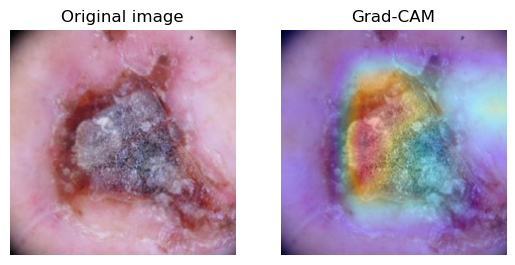

In [ ]:
image_index = 14    # This index is used to choose the target image

cam_tensor, cam_label = test_dataset[image_index]
cam_tensor = cam_tensor.to(device)

print(f"Model recall: {recall:.4f}")

if cam_label == 0:
    print("Actual label: Benign")
else:
    print("Actual label: Malignant")

cam_tensor = cam_tensor.unsqueeze(0)


# Evaluing the model on the cam image
model.eval()
with torch.inference_mode():
    output = cam_model(cam_tensor)
    probability = torch.sigmoid(output).item()
    prediction = "Malignant" if probability >= threshold else "Benign"
torch.set_grad_enabled(True)        # Re-enabling gradient
print(f"Model prediction: {prediction}")


targets = [ClassifierOutputTarget(0)]   # class identification (this problem there is only 1, because the classfier is binary)

grayscale_cam = cam(input_tensor=cam_tensor, targets=targets)
grayscale_cam = grayscale_cam[0, :]

# Image processing
img_for_visualization = cam_tensor.squeeze(0).permute(1, 2, 0).cpu().numpy()
img_for_visualization = (img_for_visualization * imagenet_std) + imagenet_mean  # This denormalizes the image
img_for_visualization = np.clip(img_for_visualization, 0, 1)

# Visualization of the results
visualization = show_cam_on_image(img_for_visualization, grayscale_cam, use_rgb=True, image_weight=0.7)

plt.subplot(1,2,1)
im_show(cam_tensor)
plt.axis('off')
plt.title('Original image')

plt.subplot(1,2,2)
plt.imshow(visualization)
plt.axis('off')
plt.title('Grad-CAM')
plt.show()

# Conclusions
### Models performances